# CV analysis — 2026-05-06 17:16:17 (slightly failed, fixed length, in PC)

Cyclic voltammetry: triangle sweep at **5 mV/s**, **+1V → -1V → +1V**.
- `ch1_MEAN_V` is unused (all zeros).
- `ch2_MEAN_V` is the readout we plot vs. the reconstructed input voltage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import medfilt

CSV_PATH = "scope_log_20260506_171617_slightly_failed_cyclic_voltametry_experiments_fixed_length_inPC.csv"
SCAN_RATE_V_PER_S = 0.005   # 5 mV/s
V_START = 1.0
V_LOW   = -1.0
V_HIGH  = 1.0
MEDIAN_WINDOW = 51          # odd; tweak if you want more/less smoothing

df = pd.read_csv(CSV_PATH)
df.head()

,elapsed_s,timestamp,ch1_MEAN_V,ch2_MEAN_V
0,0.000,2026-05-06T17:16:17.759230,0.0,5.88
1,0.257,2026-05-06T17:16:18.015503,0.0,5.88
2,0.511,2026-05-06T17:16:18.270032,0.0,5.87
3,1.018,2026-05-06T17:16:18.776804,0.0,5.87
4,1.272,2026-05-06T17:16:19.030479,0.0,5.87


In [2]:
def triangle_input_voltage(t, scan_rate=SCAN_RATE_V_PER_S,
                           v_start=V_START, v_low=V_LOW, v_high=V_HIGH):
    """Reconstruct the CV triangle waveform."""
    t = np.asarray(t, dtype=float)
    span = v_high - v_low
    half_period = span / scan_rate
    period = 2 * half_period
    t0 = (v_high - v_start) / scan_rate
    phase = np.mod(t + t0, period)
    return np.where(
        phase <= half_period,
        v_high - scan_rate * phase,
        v_low + scan_rate * (phase - half_period),
    )

df["v_input"] = triangle_input_voltage(df["elapsed_s"].to_numpy())

# Median-filter smoothing on the readout.
df["ch2_smooth"] = medfilt(df["ch2_MEAN_V"].to_numpy(), kernel_size=MEDIAN_WINDOW)

# Cycle index and sweep direction.
half_period_s = (V_HIGH - V_LOW) / SCAN_RATE_V_PER_S
period_s = 2 * half_period_s
df["cycle"] = (df["elapsed_s"] // period_s).astype(int)
df["direction"] = np.where(
    np.gradient(df["v_input"].to_numpy(), df["elapsed_s"].to_numpy()) < 0,
    "cathodic (down)", "anodic (up)"
)
df.head()

,elapsed_s,timestamp,ch1_MEAN_V,ch2_MEAN_V,v_input,ch2_smooth,cycle,direction
0,0.000,2026-05-06T17:16:17.759230,0.0,5.88,1.000000,5.87,0,cathodic (down)
1,0.257,2026-05-06T17:16:18.015503,0.0,5.88,0.998715,5.87,0,cathodic (down)
2,0.511,2026-05-06T17:16:18.270032,0.0,5.87,0.997445,5.87,0,cathodic (down)
3,1.018,2026-05-06T17:16:18.776804,0.0,5.87,0.994910,5.87,0,cathodic (down)
4,1.272,2026-05-06T17:16:19.030479,0.0,5.87,0.993640,5.87,0,cathodic (down)


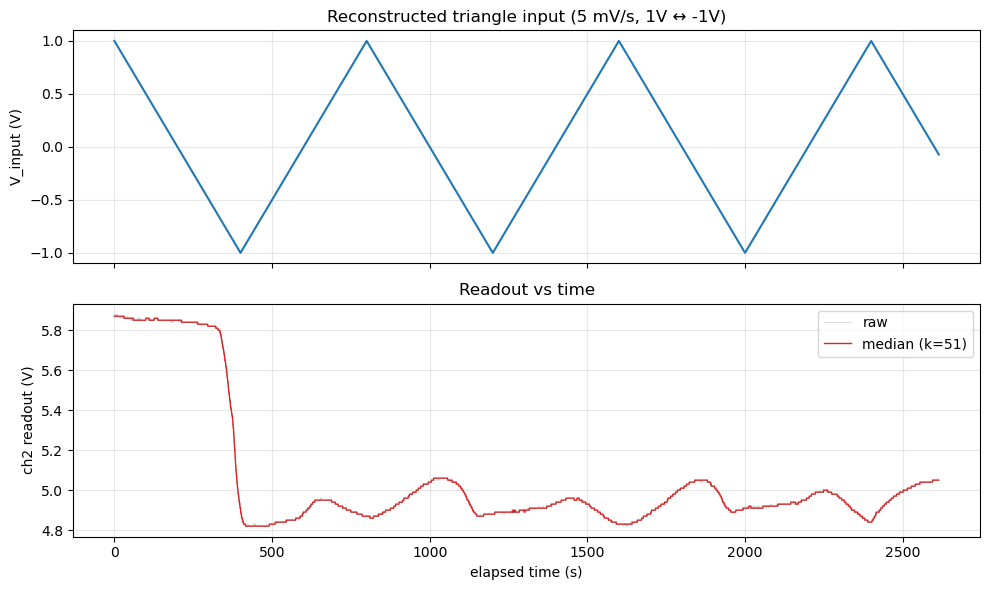

In [3]:
# Sanity check: input + readout vs time, with smoothed overlay.
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(df["elapsed_s"], df["v_input"], color="tab:blue")
axes[0].set_ylabel("V_input (V)")
axes[0].set_title("Reconstructed triangle input (5 mV/s, 1V \u2194 -1V)")
axes[0].grid(alpha=0.3)

axes[1].plot(df["elapsed_s"], df["ch2_MEAN_V"], color="lightgray", lw=0.6, label="raw")
axes[1].plot(df["elapsed_s"], df["ch2_smooth"], color="tab:red", lw=1.0,
             label=f"median (k={MEDIAN_WINDOW})")
axes[1].set_xlabel("elapsed time (s)")
axes[1].set_ylabel("ch2 readout (V)")
axes[1].set_title("Readout vs time")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

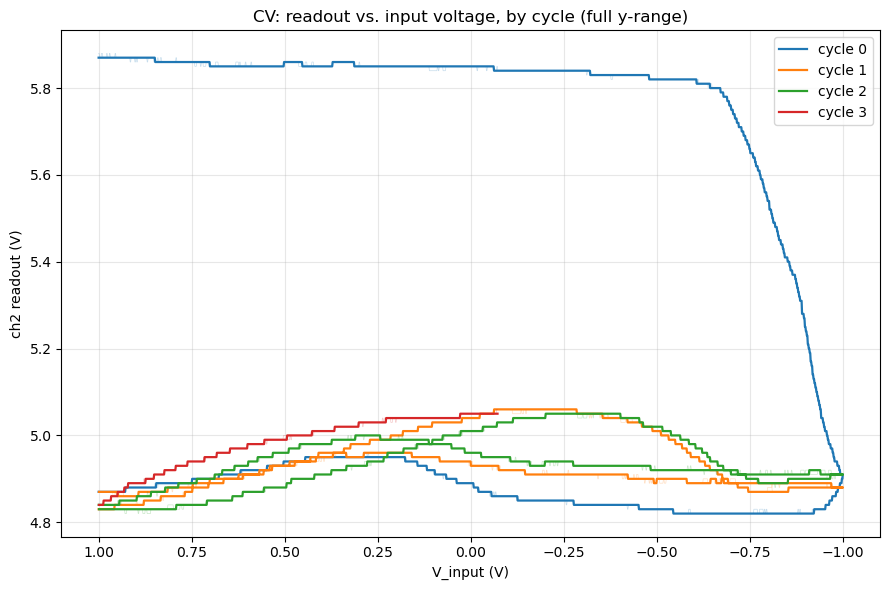

In [4]:
def plot_cv_by_cycle(df, ylim=None, title_suffix=""):
    cycles = sorted(df["cycle"].unique())
    # Discrete colors per cycle (tab10 wraps after 10 cycles, fine here with ~3-4).
    base_cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(9, 6))
    for i, c in enumerate(cycles):
        sub = df[df["cycle"] == c]
        color = base_cmap(i % 10)
        # raw faintly in the same color
        ax.plot(sub["v_input"], sub["ch2_MEAN_V"],
                color=color, lw=0.5, alpha=0.25)
        # smoothed prominent
        ax.plot(sub["v_input"], sub["ch2_smooth"],
                color=color, lw=1.6, label=f"cycle {c}")
    ax.set_xlabel("V_input (V)")
    ax.set_ylabel("ch2 readout (V)")
    ax.set_title(f"CV: readout vs. input voltage, by cycle{title_suffix}")
    ax.invert_xaxis()
    ax.grid(alpha=0.3)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Version 1: full y-range.
plot_cv_by_cycle(df, ylim=None, title_suffix=" (full y-range)")

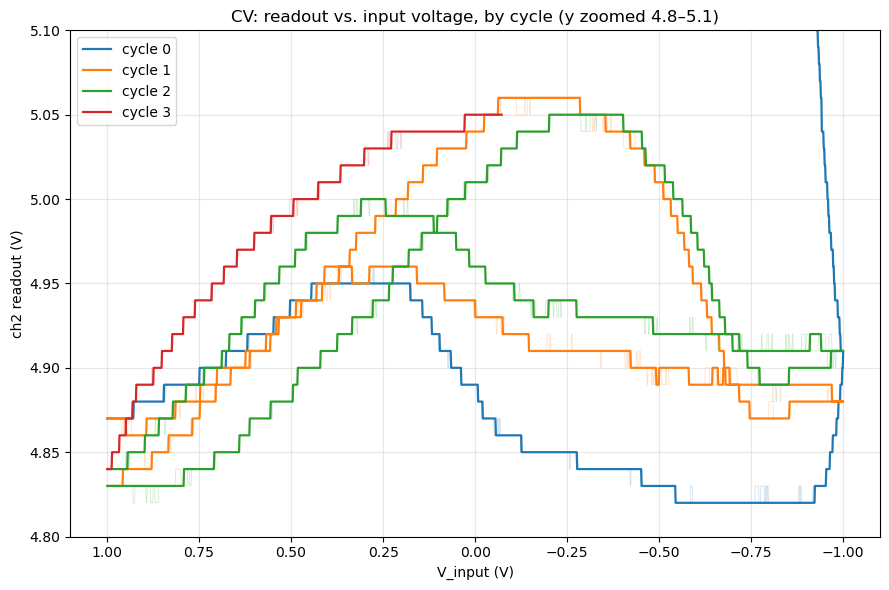

In [5]:
# Version 2: zoomed y-axis 4.8 to 5.1.
plot_cv_by_cycle(df, ylim=(4.8, 5.1), title_suffix=" (y zoomed 4.8\u20135.1)")

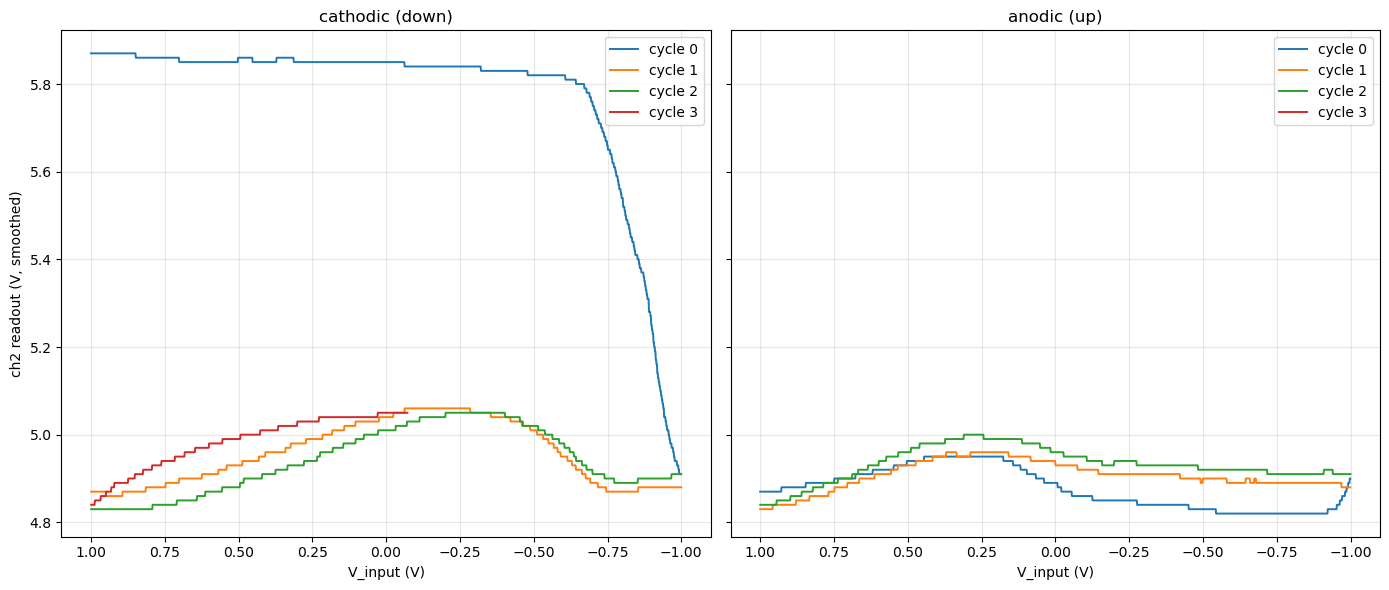

In [6]:
# Bonus: split by sweep direction (anodic vs cathodic) on the smoothed signal,
# colored per cycle so you can see hysteresis evolve.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
cycles = sorted(df["cycle"].unique())
base_cmap = plt.get_cmap("tab10")
for ax, direction in zip(axes, ["cathodic (down)", "anodic (up)"]):
    for i, c in enumerate(cycles):
        sub = df[(df["cycle"] == c) & (df["direction"] == direction)]
        ax.plot(sub["v_input"], sub["ch2_smooth"],
                color=base_cmap(i % 10), lw=1.4, label=f"cycle {c}")
    ax.set_xlabel("V_input (V)")
    ax.set_title(direction)
    ax.invert_xaxis()
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("ch2 readout (V, smoothed)")
plt.tight_layout()
plt.show()